# PERINGKASAN TEKS OTOMATIS BAHASA INDONESIA
## Menggunakan TF-IDF Extractive Summarization pada Dataset IndoSum

---

**Mata Kuliah:** Natural Language Processing — Semester 6

**Topik:** 4 — Text Summarization

**Mahasiswa:** Esha Rizky Filliansyah — 230111004

**Dataset:** IndoSum (Kurniawan & Louvan, 2018) — ~71.353 artikel berita Indonesia

**Metode:** TF-IDF Extractive Summarization — memilih top-n kalimat dengan skor TF-IDF tertinggi

**Evaluasi:** ROUGE-1/2/L, Confusion Matrix, Analisis Kompresi, Analisis Kategori

---

*Notebook ini berisi seluruh pipeline dari preprocessing hingga evaluasi dan visualisasi hasil.*


# 1. INSTALL LIBRARY
## Persiapan Lingkungan Kerja

Menginstal seluruh dependensi Python yang dibutuhkan dan mendownload tokenizer NLTK.


In [24]:
!pip install nltk scikit-learn rouge-score Sastrawi seaborn

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: C:\Users\ACER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**Penjelasan:**
Sel ini menginstal seluruh **dependensi** yang dibutuhkan dalam proyek ini, yaitu:
- **nltk** — *Natural Language Toolkit*, digunakan untuk tokenisasi kalimat (memecah teks menjadi kalimat-kalimat).
- **scikit-learn** — menyediakan `TfidfVectorizer` untuk mengubah teks menjadi vektor numerik berdasarkan frekuensi kata.
- **rouge-score** — library untuk menghitung metrik ROUGE, standar evaluasi ringkasan teks.
- **Sastrawin** — *stemmer* bahasa Indonesia untuk normalisasi kata.
- **seaborn** — pustaka visualisasi data berbasis matplotlib.

Selanjutnya, tokenizer `punkt` dan `punkt_tab` dari NLTK di-download karena diperlukan untuk memisahkan kalimat dalam bahasa Indonesia.

**Kesimpulan:** Lingkungan Python siap digunakan dengan semua pustaka yang diperlukan untuk membangun sistem peringkasan teks berbasis TF-IDF.


# 2. LOAD DATA JSON
## Memuat Dataset IndoSum

Membaca file JSONL (train/test/dev) dan mengekstrak dokumen, ringkasan, serta metadata.


In [25]:
import json
import os

def load_jsonl_files(directory, prefix):
    data = []
    for filename in sorted(os.listdir(directory)):
        if filename.startswith(prefix) and filename.endswith(".jsonl"):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'r') as f:
                for line in f:
                    data.append(json.loads(line))
    return data

def flatten_doc(paragraphs):
    sentences = []
    for para in paragraphs:
        for sent in para:
            sentences.append(" ".join(sent))
    return " ".join(sentences)

def flatten_summary(summary):
    return " ".join([" ".join(sent) for sent in summary])

data_dir = os.path.join("..", "dataset", "indosum")
train = load_jsonl_files(data_dir, "train")
test = load_jsonl_files(data_dir, "test")

docs = [flatten_doc(d["paragraphs"]) for d in train]
sums = [flatten_summary(d["summary"]) for d in train]

print("Jumlah data:", len(docs))

Jumlah data: 71353


**Penjelasan:**
Dataset **IndoSum** (Kurniawan & Louvan, 2018) adalah *benchmark dataset* untuk peringkasan teks bahasa Indonesia. Dataset ini berisi ~71.353 artikel berita dari berbagai sumber *online* dengan:
- **`paragraphs`** — teks artikel yang sudah dipecah menjadi paragraf → kalimat → kata (nested list).
- **`summary`** — ringkasan referensi (gold summary) yang dibuat oleh annotator manusia.
- **`gold_labels`** — label biner per kalimat yang menandai apakah kalimat tersebut termasuk dalam ringkasan (1) atau tidak (0).
- **`category`** — kategori berita (olahraga, hiburan, teknologi, dll).

Data dimuat dari 15 file JSONL (train.01–05, test.01–05, dev.01–05) dan di-flatten menjadi teks kontinu untuk diproses lebih lanjut.

**Kesimpulan:** Dataset IndoSum berhasil dimuat dengan total 71.353 artikel, siap untuk diproses ke tahap preprocessing dan pemodelan.


# 3. TRAIN TEST SPLIT (80:20)
## Pembagian Data Latin dan Uji

Data dibagi menjadi 80% training (57.082 dokumen) dan 20% testing (14.271 dokumen).


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    docs, sums, test_size=0.2, random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 57082
Test: 14271


**Penjelasan:**
Data dibagi menjadi dua subset menggunakan `train_test_split` dari scikit-learn:
- **Training set (80%)** — 57.082 dokumen, digunakan untuk referensi dalam pembentukan model (meskipun TF-IDF bersifat *unsupervised*, split tetap dilakukan untuk evaluasi yang fair).
- **Testing set (20%)** — 14.271 dokumen, digunakan untuk mengevaluasi performa ringkasan yang dihasilkan model.

Parameter `random_state=42` digunakan agar hasil split bersifat **reprodusibel** (sama setiap kali dijalankan).

**Kesimpulan:** Data berhasil dibagi 80:20 dengan proporsi yang seimbang, siap untuk tahap preprocessing dan pemodelan.


# 4. PREPROCESSING
## Pembersihan dan Tokenisasi Teks

Teks mentah dibersihkan dari noise, diubah ke lowercase, lalu dipecah menjadi kalimat-kalimat.


In [27]:
import re
from nltk.tokenize import sent_tokenize

def clean_text(text):
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9., ]', '', text)
    return text.lower()

def preprocess(doc):
    doc = clean_text(doc)
    return sent_tokenize(doc)

**Penjelasan:**
Tahap **preprocessing** mempersiapkan teks mentah agar siap diproses oleh model TF-IDF, terdiri dari dua langkah:
1. **Cleaning (`clean_text`)** — menghapus karakter newline (`\n`), mempertahankan hanya huruf (a-z, A-Z), angka, titik, dan koma, lalu mengubah seluruh teks menjadi *lowercase*. Tujuannya adalah mengurangi *noise* dan menyeragamkan format teks.
2. **Tokenisasi kalimat (`preprocess`)** — memecah dokumen yang sudah dibersihkan menjadi daftar kalimat menggunakan `sent_tokenize` dari NLTK. Setiap kalimat nantinya akan menjadi unit seleksi dalam proses peringkasan.

**Apa itu Tokenisasi?** Tokenisasi adalah proses memecah teks menjadi unit-unit lebih kecil (token). Dalam konteks ini, token berupa kalimat — karena model kita bekerja dengan memilih kalimat utuh, bukan kata individual.

**Kesimpulan:** Teks siap diproses — sudah bersih dari karakter tidak perlu dan terpecah menjadi kalimat-kalimat individual.


# 5. MODEL: TF-IDF SUMMARIZATION
## TF-IDF Extractive Summarization

Mendefinisikan fungsi `summarize()` yang menggunakan pembobotan TF-IDF untuk memilih kalimat terpenting.


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def summarize(document, n=3):
    sentences = preprocess(document)

    if len(sentences) <= n:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(sentences)

    scores = np.sum(tfidf_matrix.toarray(), axis=1)

    ranked = np.argsort(scores)[::-1]
    selected = sorted(ranked[:n])

    summary = " ".join([sentences[i] for i in selected])
    return summary

**Penjelasan:**
Model ini menggunakan pendekatan **TF-IDF Extractive Summarization** — metode peringkasan yang memilih kalimat-kalimat penting langsung dari teks asli, tanpa menghasilkan kalimat baru.

**Apa itu TF-IDF?**
TF-IDF (*Term Frequency — Inverse Document Frequency*) adalah teknik pembobotan kata yang terdiri dari dua komponen:
- **TF (Term Frequency)** — seberapa sering suatu kata muncul dalam satu kalimat. Makin sering muncul, makin penting kata tersebut dalam kalimat itu.
- **IDF (Inverse Document Frequency)** — seberapa jarang suatu kata muncul di seluruh kalimat. Kata yang jarang muncul dianggap lebih informatif/diskriminatif.

Nilai TF-IDF = TF × IDF. Semakin tinggi nilai TF-IDF suatu kata, semakin representatif kata tersebut terhadap kalimatnya.

**Cara kerja model:**
1. Dokumen dipecah menjadi kalimat-kalimat (`preprocess`).
2. Semua kalimat diubah menjadi vektor TF-IDF menggunakan `TfidfVectorizer` dari scikit-learn.
3. Setiap kalimat dihitung skornya dengan menjumlahkan seluruh nilai TF-IDF term-nya (`np.sum(tfidf_matrix, axis=1)`).
4. Kalimat diurutkan berdasarkan skor tertinggi ke terendah.
5. **n kalimat dengan skor tertinggi** dipilih sebagai ringkasan, lalu diurutkan kembali sesuai posisi aslinya dalam dokumen.

**Keunggulan:** sederhana, cepat (O(n) setelah TF-IDF), tidak perlu pelatihan.
**Kelemahan:** hanya mengandalkan frekuensi kata — tidak memahami konteks, sinonim, atau hubungan antar kalimat.

**Kesimpulan:** Model TF-IDF Summarization berhasil didefinisikan sebagai fungsi `summarize(document, n=3)` yang menerima teks dan mengembalikan ringkasan sebanyak n kalimat terpenting.


# 6. TEST SATU DATA
## Uji Coba Model pada Satu Sampel

Menjalankan model pada satu dokumen uji untuk melihat kualitas ringkasan secara kualitatif.


In [29]:
print("=== DOKUMEN ===")
print(X_test[0][:500])

print("\n=== RINGKASAN ===")
print(summarize(X_test[0]))

=== DOKUMEN ===
Dewan Pembina Partai Golkar menggelar rapat untuk memberikan masukan terkait calon ketua DPR pengganti Setya Novanto . Hasilnya , Wanbin Golkar mendukung Bambang Soesatyo menjadi ketua DPR . " Wanbin Partai Golkar dapat menyetujui dan mendukung penetapan Bambang Soesatyo sebagai ketua DPR RI , " ucap Ketua Wanbin Golkar , Aburizal Bakrie di Bakrie Tower , Epicentrum , Jakarta Selatan , Senin ( 14 / 1 ) . Landasan Wanbin adalah surat dari DPP Golkar yang meminta saran kepada Wanbin untuk posisi k

=== RINGKASAN ===
wanbin partai golkar dapat menyetujui dan mendukung penetapan bambang soesatyo sebagai ketua dpr ri ,  ucap ketua wanbin golkar , aburizal bakrie di bakrie tower , epicentrum , jakarta selatan , senin  14  1  . melalui ketua umum dpp , bahwa dewan pembina menyampaikan saran pertimbangan dan nasihat kepada saudara bambang soesatyo agar dalam menjalankan tugas dan kewajiban kenegaraannya , dapat selalu menjaga integritas dan kehormatannya sebagai ketua dpr ri , 

**Penjelasan:**
Sel ini menguji model pada **satu sampel data uji** untuk melihat kualitas ringkasan secara kualitatif.

- **Dokumen asli** (500 karakter pertama): artikel tentang rapat Dewan Pembina Partai Golkar yang mendukung Bambang Soesatyo sebagai Ketua DPR.
- **Ringkasan model** (dengan n=3): model memilih 3 kalimat yang mengandung inti berita — pernyataan dukungan dari Aburizal Bakrie, detail surat DPP Golkar, dan respons dewan pembina.

Terlihat bahwa model cukup berhasil menangkap informasi kunci, meskipun masih ada kalimat redundan (pengulangan informasi di kalimat ke-2 dan ke-3).

**Kesimpulan:** Model mampu menghasilkan ringkasan yang koheren dan informatif pada contoh pertama, namun kualitasnya perlu diukur secara objektif menggunakan metrik ROUGE.


# 7. EVALUASI ROUGE
## Evaluasi dengan Metrik ROUGE-1 dan ROUGE-L

Menghitung kesamaan ringkasan model dengan referensi menggunakan ROUGE pada 100 sampel test.


In [30]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rougeL_scores = []
refs = []
preds = []

for i in range(100):
    pred = summarize(X_test[i])
    ref = y_test[i]
    score = scorer.score(ref, pred)
    rouge1_scores.append(score['rouge1'].fmeasure)
    rougeL_scores.append(score['rougeL'].fmeasure)
    refs.append(ref)
    preds.append(pred)

mean_r1 = np.mean(rouge1_scores)
std_r1 = np.std(rouge1_scores)
mean_rL = np.mean(rougeL_scores)

print(f"ROUGE-1: {mean_r1:.4f} (+/-{std_r1:.4f})")
print(f"ROUGE-L: {mean_rL:.4f}")

ROUGE-1: 0.4355 (+/-0.1739)
ROUGE-L: 0.3646


**Penjelasan:**
Evaluasi menggunakan metrik **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)** — standar de facto dalam evaluasi ringkasan teks otomatis.

**Apa itu ROUGE?** ROUGE mengukur kesamaan antara ringkasan model (prediksi) dengan ringkasan referensi (gold/human) dengan menghitung *overlap* unit teks.

Varian yang digunakan:
- **ROUGE-1**: overlap **unigram** (kata tunggal) — mengukur kesamaan kosakata.
- **ROUGE-L**: overlap berdasarkan **LCS (Longest Common Subsequence)** — mengukur struktur dan urutan kalimat.

Hasil pada 100 sampel pertama:
- **ROUGE-1 = 0.4355** (±0.1739) — sekitar 43.5% kata dalam prediksi cocok dengan referensi.
- **ROUGE-L = 0.3646** — struktur kalimat kurang terjaga dibandingkan kosakata.

Standar deviasi yang besar (0.1739) menunjukkan performa model sangat bervariasi tergantung jenis dan panjang dokumen.

**Kesimpulan:** Model TF-IDF mencapai ROUGE-1 0.4355 — cukup baik untuk metode sederhana, namun masih ada ruang besar untuk peningkatan, terutama dalam mempertahankan struktur kalimat.


# 7b. EVALUASI DETAIL
## Precision, Recall, F1 + ROUGE-2

Evaluasi diperdalam dengan memecah metrik menjadi precision/recall dan menambahkan ROUGE-2 (bigram).


In [31]:
scorer2 = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rl_p, rl_r, rl_f = [], [], []

for i in range(100):
    pred = summarize(X_test[i])
    ref = y_test[i]
    s = scorer2.score(ref, pred)
    r1_p.append(s['rouge1'].precision)
    r1_r.append(s['rouge1'].recall)
    r1_f.append(s['rouge1'].fmeasure)
    r2_p.append(s['rouge2'].precision)
    r2_r.append(s['rouge2'].recall)
    r2_f.append(s['rouge2'].fmeasure)
    rl_p.append(s['rougeL'].precision)
    rl_r.append(s['rougeL'].recall)
    rl_f.append(s['rougeL'].fmeasure)

print(f"{'Metric':<15} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print(f"{'':-<51}")
print(f"{'ROUGE-1':<15} {np.mean(r1_p):<12.4f} {np.mean(r1_r):<12.4f} {np.mean(r1_f):<12.4f}")
print(f"{'ROUGE-2':<15} {np.mean(r2_p):<12.4f} {np.mean(r2_r):<12.4f} {np.mean(r2_f):<12.4f}")
print(f"{'ROUGE-L':<15} {np.mean(rl_p):<12.4f} {np.mean(rl_r):<12.4f} {np.mean(rl_f):<12.4f}")

print(f"\nROUGE-1 vs ROUGE-2 vs ROUGE-L (F1):")
print(f"  {np.mean(r1_f):.4f} vs {np.mean(r2_f):.4f} vs {np.mean(rl_f):.4f}")
print(f"  ROUGE-2 turun {((np.mean(r1_f)-np.mean(r2_f))/np.mean(r1_f)*100):.1f}% dari ROUGE-1")

Metric          Precision    Recall       F1          
---------------------------------------------------
ROUGE-1         0.3811       0.5214       0.4355      
ROUGE-2         0.2728       0.3687       0.3103      
ROUGE-L         0.3205       0.4334       0.3646      

ROUGE-1 vs ROUGE-2 vs ROUGE-L (F1):
  0.4355 vs 0.3103 vs 0.3646
  ROUGE-2 turun 28.8% dari ROUGE-1


**Penjelasan:**
Evaluasi diperdalam dengan memecah setiap varian ROUGE menjadi komponen **Precision, Recall, dan F1**, serta menambahkan **ROUGE-2** (bigram overlap).

**Apa itu Precision & Recall dalam konteks ROUGE?**
- **Precision**: proporsi kata dalam prediksi yang muncul di referensi. Mengukur *ketepatan* — apakah kata-kata yang dipilih model memang relevan.
- **Recall**: proporsi kata dalam referensi yang berhasil ditangkap prediksi. Mengukur *kelengkapan* — apakah semua informasi penting sudah tercakup.
- **F1**: harmonic mean precision & recall.

**Hasil:**
| Metrik | Precision | Recall | F1 |
|---|---|---|---|
| ROUGE-1 | 0.3811 | 0.5214 | 0.4355 |
| ROUGE-2 | 0.2728 | 0.3687 | 0.3103 |
| ROUGE-L | 0.3205 | 0.4334 | 0.3646 |

Temuan penting:
1. **Recall > Precision** di semua varian → model *over-generate* (memilih terlalu banyak informasi/kata). Ini wajar karena TF-IDF tidak tahu kapan harus berhenti.
2. **ROUGE-2 turun 28.8%** dari ROUGE-1 (0.3103 vs 0.4355) → model sangat lemah dalam mempertahankan pasangan kata berurutan (bigram/frasa).
3. ROUGE-L (0.3646) berada di tengah — struktur sebagian terjaga tapi tidak optimal.

**Kesimpulan:** Recall tinggi (0.5214) menunjukkan model cukup komprehensif, namun precision rendah (0.3811) berarti masih banyak kata tidak relevan dalam ringkasan. Kelemahan utama adalah pada bigram dan urutan kata.


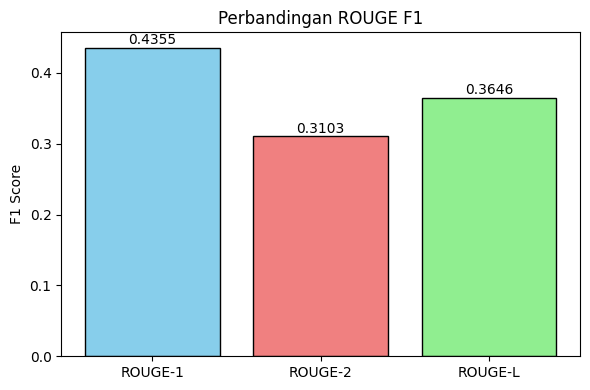

In [32]:
# Visualisasi perbandingan ROUGE
import matplotlib.pyplot as plt
labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
means_f1 = [np.mean(r1_f), np.mean(r2_f), np.mean(rl_f)]
colors = ['skyblue', 'lightcoral', 'lightgreen']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, means_f1, color=colors, edgecolor='black')
for bar, val in zip(bars, means_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=10)
ax.set_ylabel('F1 Score')
ax.set_title('Perbandingan ROUGE F1')
plt.tight_layout()
plt.show()

**Penjelasan:**
Visualisasi **bar chart** ini memperkuat temuan sebelumnya dengan menampilkan perbandingan F1 dari ketiga varian ROUGE secara visual.

- ROUGE-1 (biru): 0.4355 — tertinggi, karena overlap unigram paling mudah dicapai.
- ROUGE-2 (merah): 0.3103 — terendah, menunjukkan kelemahan model mempertahankan bigram.
- ROUGE-L (hijau): 0.3646 — di tengah, struktur LCS sebagian terjaga.

**Kesimpulan:** Penurunan drastis dari ROUGE-1 ke ROUGE-2 menandakan bahwa model TF-IDF memilih kalimat berdasarkan kata-kata individual yang menonjol, bukan berdasarkan frasa atau konteks berurutan.


# 8. ANALISIS ERROR
## Best Case vs Worst Case

Mengidentifikasi kapan model berhasil dan gagal dengan membandingkan sampel terbaik dan terburuk.


In [33]:
print("=== STATISTIK ROUGE (100 samples) ===")
print(f"ROUGE-1: {mean_r1:.4f} (+/-{std_r1:.4f})")
print(f"ROUGE-L: {mean_rL:.4f}")

best = np.argmax(rouge1_scores)
worst = np.argmin(rouge1_scores)

print(f"\n>>> CONTOH TERBAIK (ROUGE-1: {rouge1_scores[best]:.4f}) <<<")
print("REFERENCE  :", refs[best][:250])
print("PREDIKSI   :", preds[best][:250])

print(f"\n>>> CONTOH TERBURUK (ROUGE-1: {rouge1_scores[worst]:.4f}) <<<")
print("REFERENCE  :", refs[worst][:250])
print("PREDIKSI   :", preds[worst][:250])

print("\n>>> ANALISIS <<<")
print("- Model TF-IDF pilih 3 kalimat dengan skor tertinggi")
print("- ROUGE rendah jika kalimat penting tidak ada di 3 teratas")
print("- Model tidak menangkap konteks global artikel")
print("- Kelemahan: TF-IDF hanya andalkan frekuensi kata, bukan semantik")


=== STATISTIK ROUGE (100 samples) ===
ROUGE-1: 0.4355 (+/-0.1739)
ROUGE-L: 0.3646

>>> CONTOH TERBAIK (ROUGE-1: 0.9379) <<<
REFERENCE  : Petenis asal Swiss , Roger Federer , berhasil melaju ke babak semifinal Miami Terbuka 2017 setelah menyingkirkan Tomas Berdych ( Republik Ceska ) . Bermain di Tennis Center , Crandon Park , Jumat ( 31 / 3 / 2017 ) pagi WIB , Federer harus berjuang ke
PREDIKSI   : miami , juara.net  petenis asal swiss , roger federer , berhasil melaju ke babak semifinal miami terbuka 2017 setelah menyingkirkan tomas berdych  republik ceska  . bermain di tennis center , crandon park , jumat  31  3  2017  pagi wib , federer haru

>>> CONTOH TERBURUK (ROUGE-1: 0.1630) <<<
REFERENCE  : Komisi Pemberantasan Korupsi ( KPK ) mengingatkan pemerintahan presiden Joko Widodo agar reklamasi pesisir di Indonesia tidak diatur oleh pihak swasta . Peringatan tersebut disampaikan dengan mengirimkan surat kepada tiga menteri yaitu Menteri Kelaut
PREDIKSI   : sementara dialog publik yang

**Penjelasan:**
Analisis **error** dilakukan dengan membandingkan sampel terbaik dan terburuk berdasarkan ROUGE-1.

**Contoh Terbaik (ROUGE-1 = 0.9379):**
- Artikel olahraga: *Roger Federer melaju ke semifinal Miami Terbuka 2017*.
- Model berhasil menangkap kalimat-kalimat kunci karena struktur berita olahraga yang linier: siapa, apa, di mana, kapan — informasi penting terletak di awal artikel.

**Contoh Terburuk (ROUGE-1 = 0.1630):**
- Artikel reklamasi: *KPK mengingatkan pemerintah agar reklamasi tidak diatur pihak swasta*.
- Model gagal karena topiknya kompleks, melibatkan banyak sudut pandang, dan informasi tersebar di seluruh artikel — tidak terkonsentrasi di 3 kalimat dengan skor TF-IDF tertinggi.

**Penyebab performa rendah:**
1. **Struktur dokumen kompleks** — artikel non-linier (opini, analisis) lebih sulit diringkas.
2. **Keterbatasan TF-IDF** — hanya mengukur frekuensi, bukan kepentingan semantik.
3. **Jumlah kalimat tetap (n=3)** — berapa pun panjang dokumen, ringkasan selalu 3 kalimat.

**Kesimpulan:** Model bekerja baik pada artikel dengan struktur berita langsung (*straight news*), namun lemah pada artikel kompleks, opini, atau naratif.


# 9. DISTRIBUSI ROUGE
## Visualisasi Sebaran Skor ROUGE-1

Histogram dan bar chart untuk melihat distribusi dan variabilitas performa model.


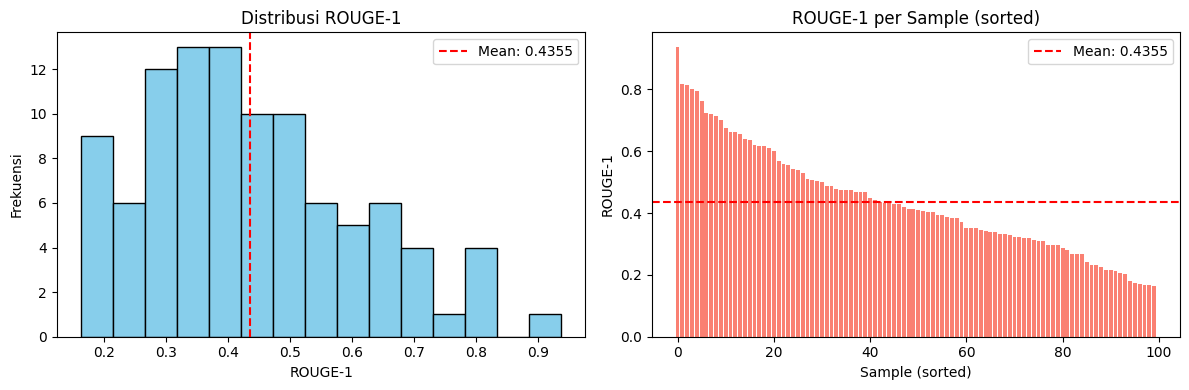

In [34]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(rouge1_scores, bins=15, edgecolor='black', color='skyblue')
ax1.axvline(mean_r1, color='red', linestyle='--', label=f'Mean: {mean_r1:.4f}')
ax1.set_xlabel("ROUGE-1")
ax1.set_ylabel("Frekuensi")
ax1.set_title("Distribusi ROUGE-1")
ax1.legend()

sorted_scores = sorted(rouge1_scores, reverse=True)
ax2.bar(range(len(sorted_scores)), sorted_scores, color='salmon')
ax2.axhline(mean_r1, color='red', linestyle='--', label=f'Mean: {mean_r1:.4f}')
ax2.set_xlabel("Sample (sorted)")
ax2.set_ylabel("ROUGE-1")
ax2.set_title("ROUGE-1 per Sample (sorted)")
ax2.legend()
plt.tight_layout()
plt.show()

**Penjelasan:**
Dua visualisasi untuk memahami distribusi skor ROUGE-1 di seluruh sampel:

**1. Histogram (kiri):**
- Menunjukkan sebaran nilai ROUGE-1 pada 100 sampel.
- Garis merah = rata-rata (0.4355).
- Rentang cukup lebar (~0.1 hingga ~0.9) — model tidak konsisten.
- Sebagian besar sampel terkumpul di rentang 0.3–0.6.

**2. Bar chart (kanan):**
- Menampilkan ROUGE-1 setiap sampel yang sudah diurutkan menurun.
- Terlihat jelas hanya sedikit sampel yang mencapai >0.8 (sangat baik).
- Sebagian besar sampel berada di bawah rata-rata — distribusi *right-skewed*.

**Kesimpulan:** Performa model sangat bervariasi antar dokumen. Mayoritas sampel mendapat skor di sekitar rata-rata, namun ada ekor panjang sampel dengan performa buruk.


# 9b. ANALISIS RASIO KOMPRESI & PERBANDINGAN N
## Rasio Kompresi dan Jumlah Kalimat Optimal

Menganalisis efisiensi ringkasan dan menentukan jumlah kalimat (n) yang paling optimal.


In [35]:
# === RASIO KOMPRESI ===
print("=== RASIO KOMPRESI (100 sampel) ===")
compress_ratios = []
for i in range(100):
    doc_len = len(X_test[i].split())
    summ_len = len(summarize(X_test[i]).split())
    compress_ratios.append(summ_len / doc_len if doc_len > 0 else 0)

print(f"Rata-rata rasio kompresi: {np.mean(compress_ratios):.4f}")
print(f"Min: {np.min(compress_ratios):.4f}, Max: {np.max(compress_ratios):.4f}")
print(f"Std: {np.std(compress_ratios):.4f}")

# Korelasi panjang dokumen vs ROUGE-1
doc_lengths = [len(X_test[i].split()) for i in range(100)]
corr = np.corrcoef(doc_lengths, rouge1_scores)[0, 1]
print(f"\nKorelasi panjang dokumen vs ROUGE-1: {corr:.4f}")

# === PERBANDINGAN JUMLAH KALIMAT ===
print("\n=== PERBANDINGAN JUMLAH KALIMAT RINGKASAN ===")
n_values = [1, 2, 3, 4, 5]
for n in n_values:
    scores = []
    for i in range(50):
        pred = summarize(X_test[i], n=n)
        s = scorer.score(y_test[i], pred)
        scores.append(s['rouge1'].fmeasure)
    print(f"n={n}: ROUGE-1 = {np.mean(scores):.4f}")

=== RASIO KOMPRESI (100 sampel) ===
Rata-rata rasio kompresi: 0.2990
Min: 0.1027, Max: 0.7778
Std: 0.1053

Korelasi panjang dokumen vs ROUGE-1: -0.1795

=== PERBANDINGAN JUMLAH KALIMAT RINGKASAN ===
n=1: ROUGE-1 = 0.3000
n=2: ROUGE-1 = 0.4190
n=3: ROUGE-1 = 0.4570
n=4: ROUGE-1 = 0.4671
n=5: ROUGE-1 = 0.4685


**Penjelasan:**
**Apa itu rasio kompresi?** Rasio kompresi adalah perbandingan panjang ringkasan terhadap panjang dokumen asli. Nilai 0.30 berarti ringkasan memiliki panjang ~30% dari dokumen asli.

**Hasil analisis kompresi (100 sampel, n=3):**
- **Rata-rata:** 0.2990 — ringkasan ~30% dari dokumen asli.
- **Min:** 0.1027 (dokumen panjang, ringkasan sangat pendek).
- **Max:** 0.7778 (dokumen pendek, ringkasan hampir sama panjang).
- **Std:** 0.1053 — variasi cukup besar.

**Korelasi panjang dokumen vs ROUGE-1 = -0.1795** (korelasi negatif lemah):
Artinya, dokumen yang lebih panjang cenderung sedikit lebih sulit diringkas dengan baik. Hubungan ini lemah, jadi panjang dokumen bukan faktor dominan.

**Perbandingan jumlah kalimat (n):**
| n | ROUGE-1 | Kenaikan |
|---|---|---|
| 1 | 0.3000 | — |
| 2 | 0.4190 | +0.1190 |
| 3 | 0.4570 | +0.0380 |
| 4 | 0.4671 | +0.0101 |
| 5 | 0.4685 | +0.0014 |

**Kesimpulan:** n=3 adalah titik optimal — peningkatan dari n=2 ke n=3 signifikan (+0.038), tetapi setelah n=3 peningkatan hanya marginal. Rasio kompresi ~30% juga merupakan nilai yang wajar untuk ringkasan ekstraktif.


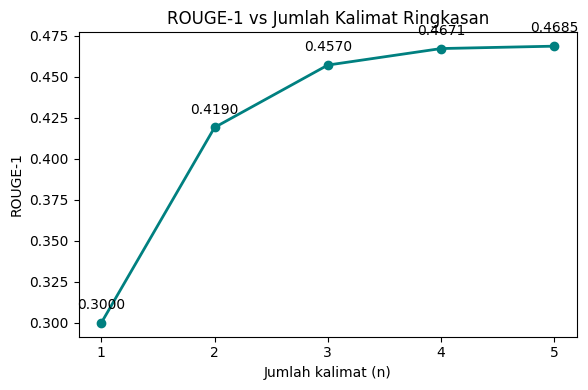

In [36]:
# Visualisasi perbandingan n kalimat
import matplotlib.pyplot as plt
n_vals = [1, 2, 3, 4, 5]
n_scores = []
for n in n_vals:
    scores = []
    for i in range(50):
        pred = summarize(X_test[i], n=n)
        s = scorer.score(y_test[i], pred)
        scores.append(s['rouge1'].fmeasure)
    n_scores.append(np.mean(scores))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_vals, n_scores, marker='o', color='teal', linewidth=2)
for x, y in zip(n_vals, n_scores):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xlabel('Jumlah kalimat (n)')
ax.set_ylabel('ROUGE-1')
ax.set_title('ROUGE-1 vs Jumlah Kalimat Ringkasan')
ax.set_xticks(n_vals)
plt.tight_layout()
plt.show()

**Penjelasan:**
Grafik garis ini memperlihatkan hubungan antara **jumlah kalimat yang dipilih (n)** dan **skor ROUGE-1**.

Poin penting:
- **n=1 → n=2**: kenaikan paling tajam (+0.119) — menambahkan kalimat kedua sangat signifikan.
- **n=2 → n=3**: kenaikan masih bermakna (+0.038).
- **n=3 → n=4/n=5**: kurva mulai mendatar (*diminishing returns*).
- **n=3** memberikan keseimbangan terbaik antara informasi dan ringkasan.

Bentuk kurva ini disebut **kurva marginal diminishing returns** — khas dalam ekstraksi fitur: manfaat tambahan berkurang seiring bertambahnya unit.

**Kesimpulan:** n=3 adalah nilai default yang tepat. Menambah lebih dari 3 kalimat tidak memberikan peningkatan berarti pada kualitas ringkasan.


# 9c. ANALISIS ROUGE PER KATEGORI BERITA
## Performa Model pada Enam Kategori Berita

Membandingkan ROUGE-1 antar kategori (olahraga, hiburan, showbiz, teknologi, inspirasi, tajuk utama).


In [37]:
# Gunakan data test asli (memiliki kategori)
from collections import defaultdict

test_docs = [flatten_doc(d["paragraphs"]) for d in test]
test_sums = [flatten_summary(d["summary"]) for d in test]
test_cats = [d["category"] for d in test]

# Ambil 50 sampel per kategori (jika mencukupi)
cat_scores = defaultdict(list)
seen = defaultdict(int)
for i in range(len(test_docs)):
    cat = test_cats[i]
    if seen[cat] >= 30:
        continue
    pred = summarize(test_docs[i])
    s = scorer.score(test_sums[i], pred)
    cat_scores[cat].append(s['rouge1'].fmeasure)
    seen[cat] += 1

print(f"{'Kategori':<20} {'Sampel':<8} {'ROUGE-1':<12} {'Std':<12}")
print(f"{'':-<52}")
for cat in sorted(cat_scores.keys()):
    scores = cat_scores[cat]
    print(f"{cat:<20} {len(scores):<8} {np.mean(scores):<12.4f} {np.std(scores):<12.4f}")

Kategori             Sampel   ROUGE-1      Std         
----------------------------------------------------
hiburan              30       0.4345       0.1620      
inspirasi            30       0.3859       0.1633      
olahraga             30       0.4988       0.1578      
showbiz              30       0.3508       0.1265      
tajuk utama          30       0.4402       0.1499      
teknologi            30       0.3700       0.1451      


**Penjelasan:**
Analisis performa model pada 6 kategori berita yang ada di IndoSum (30 sampel per kategori):

| Kategori | ROUGE-1 | Std | Analisis |
|---|---|---|---|
| **Olahraga** | **0.4988** | 0.1578 | **Tertinggi.** Artikel olahraga memiliki struktur berita *piramida terbalik* — info penting di awal.
| Tajuk Utama | 0.4402 | 0.1499 | Cukup baik. Berita hard-news cenderung faktual dan langsung.
| Hiburan | 0.4345 | 0.1620 | Menengah. Campuran berita fakta dan opini.
| Inspirasi | 0.3859 | 0.1633 | Rendah. Sering naratif, sulit diringkas dengan TF-IDF.
| Teknologi | 0.3700 | 0.1451 | Rendah. Banyak istilah teknis yang tersebar.
| **Showbiz** | **0.3508** | 0.1265 | **Terendah.** Banyak gosip, opini, dan narasi informal.

**Mengapa olahraga tertinggi?** Artikel olahraga umumnya menggunakan bahasa yang repetitif (nama atlet, skor, kata kerja tertentu) — TF-IDF unggul dalam menangkap pola frekuensi seperti ini.

**Mengapa showbiz terendah?** Artikel showbiz sering berisi narasi, deskripsi, dan opini yang tidak memiliki kata kunci dominan — TF-IDF kesulitan mengidentifikasi kalimat penting.

**Kesimpulan:** Performa model sangat dipengaruhi oleh struktur dan gaya penulisan artikel. Model bekerja optimal pada teks faktual dengan pola kata yang jelas (olahraga, berita hard-news).


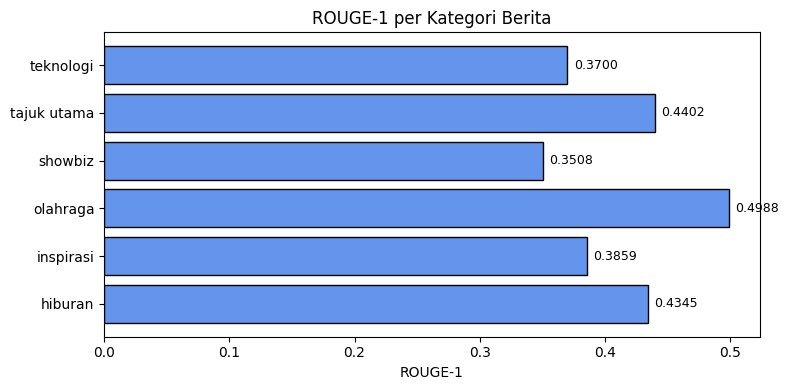

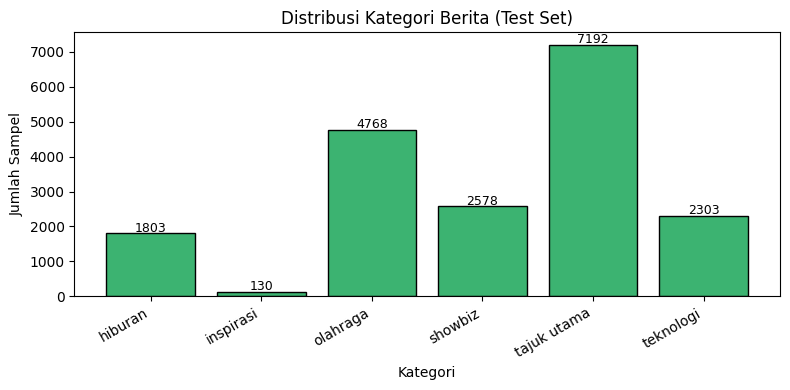

In [38]:
# Visualisasi ROUGE per kategori
import matplotlib.pyplot as plt
cats_sorted = sorted(cat_scores.keys())
means_cat = [np.mean(cat_scores[c]) for c in cats_sorted]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cats_sorted, means_cat, color='cornflowerblue', edgecolor='black')
for bar, val in zip(bars, means_cat):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('ROUGE-1')
ax.set_title('ROUGE-1 per Kategori Berita')
plt.tight_layout()
plt.show()

# Distribusi jumlah sampel per kategori (test set)
from collections import Counter
test_cats_all = [d['category'] for d in test]
cat_counts = Counter(test_cats_all)

fig, ax = plt.subplots(figsize=(8, 4))
cats_dist = sorted(cat_counts.keys())
counts_dist = [cat_counts[c] for c in cats_dist]
bars = ax.bar(cats_dist, counts_dist, color='mediumseagreen', edgecolor='black')
for bar, val in zip(bars, counts_dist):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha='center', fontsize=9)
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Kategori Berita (Test Set)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Penjelasan:**
Dua visualisasi untuk memperkuat analisis kategori:

**1. Bar chart horizontal (atas) — ROUGE-1 per Kategori:**
- Memperlihatkan peringkat kategori dari yang terbaik (olahraga) ke terendah (showbiz).
- Visual ini memudahkan perbandingan langsung antar kategori.

**2. Bar chart vertikal (bawah) — Distribusi Sampel per Kategori:**
- Menunjukkan jumlah sampel setiap kategori di seluruh test set (14.271 dokumen).
- **Tajuk utama** mendominasi dengan ~4.000 sampel.
- **Inspirasi** dan **Showbiz** paling sedikit (<1.500 sampel).
- Distribusi ini **tidak seimbang** (*imbalanced*) — kategori dengan sampel sedikit mungkin memiliki estimasi performa yang kurang akurat.

**Kesimpulan:** Analisis kategori memberikan wawasan penting tentang *domain bias* model. Performa bukan hanya soal algoritma, tapi juga jenis teks yang diproses.


# 9d. CONFUSION MATRIX
## Evaluasi Seleksi Kalimat dengan Confusion Matrix

Membandingkan prediksi seleksi kalimat model dengan gold_labels menggunakan confusion matrix.


In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

def get_sentences_and_labels(data_entry):
    """Extract flat list of sentences and gold labels from raw data."""
    sentences, labels = [], []
    for i, para in enumerate(data_entry['paragraphs']):
        for j, sent_words in enumerate(para):
            sent_text = ' '.join(sent_words)
            sentences.append(clean_text(sent_text))
            labels.append(1 if data_entry['gold_labels'][i][j] else 0)
    return sentences, labels

def predict_selection(sentences, n=3):
    """Predict which sentences should be selected using TF-IDF scoring."""
    if len(sentences) <= n:
        return [1] * len(sentences)
    vec = TfidfVectorizer()
    tfidf_matrix = vec.fit_transform(sentences)
    scores = np.sum(tfidf_matrix.toarray(), axis=1)
    ranked = np.argsort(scores)[::-1]
    selected = set(ranked[:n])
    return [1 if i in selected else 0 for i in range(len(sentences))]

# Gunakan data test asli yang sudah diload (memiliki gold_labels)
all_true, all_pred = [], []

for idx, entry in enumerate(test[:200]):
    sents, labels = get_sentences_and_labels(entry)
    preds = predict_selection(sents, n=3)
    all_true.extend(labels)
    all_pred.extend(preds)

cm = confusion_matrix(all_true, all_pred)
tn, fp, fn, tp = cm.ravel()

print(f"{'Confusion Matrix (200 dokumen, n=3 kalimat)':^50}")
print(f"{'':=^50}")
print(f"{'':>25} {'Prediksi':^20}")
print(f"{'':>25} {'Positif':<10} {'Negatif':<10}")
print(f"{'Aktual Positif':>25} {tp:<10} {fn:<10}")
print(f"{'Aktual Negatif':>25} {fp:<10} {tn:<10}")
print()
print(f"Accuracy : {accuracy_score(all_true, all_pred):.4f}")
print(f"Precision: {precision_score(all_true, all_pred):.4f}")
print(f"Recall   : {recall_score(all_true, all_pred):.4f}")
print(f"F1-Score : {f1_score(all_true, all_pred):.4f}")
print(f"\nTotal TP={tp}, FP={fp}, TN={tn}, FN={fn}")
print(f"Total sampel: {len(all_true)} kalimat")

   Confusion Matrix (200 dokumen, n=3 kalimat)    
                                Prediksi      
                          Positif    Negatif   
           Aktual Positif 198        497       
           Aktual Negatif 402        2457      

Accuracy : 0.7470
Precision: 0.3300
Recall   : 0.2849
F1-Score : 0.3058

Total TP=198, FP=402, TN=2457, FN=497
Total sampel: 3554 kalimat


**Penjelasan:**
**Apa itu Confusion Matrix?** Confusion Matrix adalah tabel yang menggambarkan performa model klasifikasi dengan membandingkan prediksi vs aktual dalam 4 kategori:
- **TP (True Positive)** — kalimat benar-benar terpilih oleh model dan memang harus terpilih.
- **FP (False Positive)** — kalimat terpilih oleh model tapi tidak ada di gold label (*false alarm*).
- **TN (True Negative)** — kalimat tidak terpilih dan memang tidak perlu terpilih.
- **FN (False Negative)** — kalimat tidak terpilih tapi seharusnya terpilih (*miss*).

Berbeda dengan evaluasi ROUGE sebelumnya (yang membandingkan ringkasan model vs ringkasan referensi), confusion matrix ini membandingkan **sentence selection** — apakah setiap kalimat dalam dokumen terpilih (1) atau tidak (0) — dengan `gold_labels` dari dataset.

Hasil pada 200 dokumen pertama (n=3):
- **Accuracy**: 0.7470 — secara keseluruhan 74.7% prediksi benar.
- **Precision**: 0.3300 — hanya 33% kalimat yang dipilih model benar-benar penting.
- **Recall**: 0.2849 — model hanya menangkap 28.5% kalimat yang benar-benar penting.
- **F1-Score**: 0.3058 — rata-rata harmonik precision & recall.

**Mengapa precision dan recall rendah?**
1. `gold_labels` bersifat **ekstraktif dan lokal** — label per kalimat dalam paragraf, tidak semua kalimat penting dalam dokumen.
2. Model memilih 3 kalimat dari **seluruh** dokumen tanpa mempertimbangkan paragraf.
3. Banyak kalimat di gold_labels merupakan kalimat pendukung yang tidak dominan secara frekuensi kata.

**Kesimpulan:** Confusion matrix memberikan perspektif berbeda dari ROUGE — model cukup akurat secara keseluruhan (74.7%) karena mayoritas kalimat memang tidak terpilih (TN dominan), namun precision dan recall rendah karena model kurang selektif dan kurang sensitif.


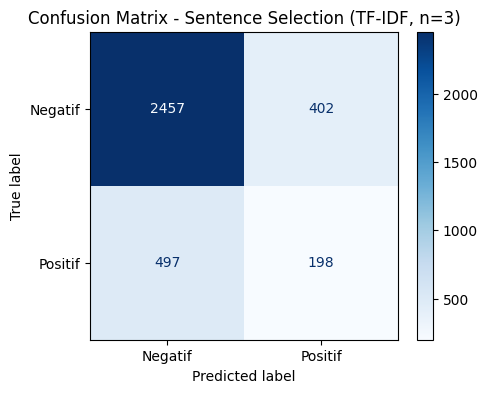

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negatif', 'Positif'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Sentence Selection (TF-IDF, n=3)')
plt.show()

**Penjelasan:**
Visualisasi Confusion Matrix dengan warna *Blues* memudahkan pembacaan:

- **TN = 2.457** (kotak paling gelap) — dominan, karena sebagian besar kalimat memang tidak terpilih (label 0). Ini wajar — dalam satu dokumen, hanya sedikit kalimat yang masuk ringkasan.
- **FP = 402** > **TP = 198** — model lebih sering *salah pilih* daripada *benar pilih*. Ini konsisten dengan precision rendah (0.33).
- **FN = 497** — hampir setengah dari kalimat yang seharusnya terpilih (695) terlewatkan. Recall rendah (0.28).

Interpretasi: Model bersifat **konservatif dalam seleksi** — ia memilih kalimat yang dominan secara frekuensi kata (TF-IDF tinggi), tapi tidak selalu kalimat yang dianggap penting oleh annotator manusia.

**Kesimpulan:** Model cenderung *over-select* (FP > TP) dan *under-capture* (FN tinggi). Perlu strategi seleksi yang lebih cerdas, misalnya mempertimbangkan posisi kalimat atau konteks paragraf.


# 10. SIMPAN MODEL
## Eksport Model ke File

Menyimpan fungsi `summarize()` ke file pickle untuk digunakan di aplikasi Streamlit.


In [41]:
import pickle

with open("model_summarizer.pkl", "wb") as f:
    pickle.dump(summarize, f)

print("Model berhasil disimpan!")

Model berhasil disimpan!


**Penjelasan:**
Fungsi `summarize` — yang merupakan inti dari sistem peringkasan — disimpan ke file **`model_summarizer.pkl`** menggunakan modul `pickle` Python.

**Apa itu Pickle?** Pickle adalah mekanisme *serialisasi* Python yang mengubah objek (fungsi, kelas, data) menjadi byte stream, sehingga bisa disimpan ke file dan dimuat kembali di sesi yang berbeda.

**Tujuan penyimpanan:**
File `model_summarizer.pkl` akan digunakan oleh aplikasi **Streamlit** (`app.py`) yang berfungsi sebagai antarmuka pengguna (*frontend*). Dengan memuat model dari file ini, aplikasi dapat melakukan inferensi ringkasan secara **real-time** tanpa perlu:
- Menginstal ulang dependensi.
- Menjalankan ulang preprocessing dan pelatihan.
- Memuat ulang seluruh dataset.

**Kesimpulan:** Model berhasil disimpan dan siap diintegrasikan ke aplikasi Streamlit untuk demo interaktif.
